### Wrap-Style Hook（包裹式钩子）

节点式钩子（`before_*` / `after_*`）是在节点**前后**各跑一段逻辑；包裹式钩子（`wrap_model_call` / `wrap_tool_call`）则把整次调用**包在中间**：

它拿到两个参数：

- `request`：本次调用的请求（模型调用是 `ModelRequest`，工具调用是 `ToolCallRequest`）
- `handler`：真正执行调用的回调

你可以在调用 `handler(request)` 之前**修改请求**、之后**改写响应**、失败时**重试**，甚至**根本不调用** `handler`（短路）。

| 钩子 | 包裹对象 | 函数签名 |
| --- | --- | --- |
| `@wrap_model_call` | 模型调用 | `(request: ModelRequest, handler) -> ModelResponse \| AIMessage` |
| `@wrap_tool_call` | 工具调用 | `(request: ToolCallRequest, handler) -> ToolMessage \| Command` |

> 多个包裹钩子会自动组合：**先定义的在外层**（outermost），后定义的在内层。

#### 请求与响应对象

**`ModelRequest`** 常用字段（用 `request.override(...)` 生成新请求，不可变）：

| 字段 | 说明 |
| --- | --- |
| `model` | 本次使用的模型实例 |
| `messages` | 消息列表（不含系统消息） |
| `system_message` | 系统消息（`SystemMessage`） |
| `tools` / `tool_choice` | 可用工具与选择策略 |
| `state` | Agent 状态（可读 `state["messages"]`） |
| `runtime` | 运行时上下文（`request.runtime.context` 等） |
| `model_settings` | 模型设置（如 `temperature`） |

**`ModelResponse`**：`result`（`list[BaseMessage]`）与 `structured_response`。

**`ToolCallRequest`** 字段：`tool_call`（含 `name`/`args`/`id`）、`tool`、`state`、`runtime`，用 `request.override(tool_call=...)` 修改调用。

In [19]:
import os

from dotenv import load_dotenv
from langchain.agents import create_agent
from langchain.agents.middleware import wrap_model_call, wrap_tool_call
from langchain.chat_models import init_chat_model
from langchain_core.messages import AIMessage, SystemMessage, ToolMessage
from langchain_core.tools import tool
from IPython.display import Image, display

load_dotenv(override=True)

model = init_chat_model(
    api_base=os.getenv("DEEPSEEK_API_BASE"),
    api_key=os.getenv("DEEPSEEK_API_KEY"),
    model="deepseek-flash",
    model_provider="deepseek",
    model_kwargs={"reasoning_effort": "none"},
)


@tool
def add(a: int, b: int) -> int:
    """计算两数之和。

    :param a: 第一个加数
    :param b: 第二个加数
    """
    return a + b


/Users/lijixu/PycharmProjects/langchain_demo/.venv/lib/python3.14/site-packages/langchain/chat_models/base.py:516: UserWarning: Parameters {'reasoning_effort'} should be specified explicitly. Instead they were passed in as part of `model_kwargs` parameter.
  return _init_chat_model_helper(


#### 案例 1：观察包裹与执行顺序

outer 进入
inner 进入
inner 退出
outer 退出
{'messages': [HumanMessage(content='说一句话', additional_kwargs={}, response_metadata={}, id='994e01d3-adfa-427b-9566-ed1022b11d8e'), AIMessage(content='当然，但这句话要送给你：\n\n**“愿你在每一个平凡的日子里，都能找到属于自己的那束光。”**', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 6, 'total_tokens': 30, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 6}, 'model_provider': 'deepseek', 'model_name': 'deepseek-flash', 'system_fingerprint': 'aeb56401ca74e127821c4f9126dcb669', 'id': 'dc82a1e5-c76d-466b-aed0-c0aa5a16e97c', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a0cde4-a285-7343-b838-3c3da0bf04b9-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 6, 'output_tokens': 24, 'total_tokens': 30, 'input_token

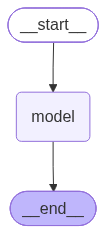

In [20]:
# 两个 wrap_model_call：先定义的在外层
@wrap_model_call
def outer(request, handler):
    print("outer 进入")
    response = handler(request)
    print("outer 退出")
    return response


@wrap_model_call
def inner(request, handler):
    print("inner 进入")
    response = handler(request)
    print("inner 退出")
    return response


agent_order = create_agent(model=model, middleware=[outer, inner])
print(agent_order.invoke({"messages": [{"role": "user", "content": "说一句话"}]}))
display(Image(agent_order.get_graph().draw_mermaid_png()))


# 输出顺序：outer 进入 -> inner 进入 -> inner 退出 -> outer 退出
# 说明「先定义 = 外层」，handler 就是内层逻辑


#### 案例 2：修改请求（override）

In [21]:
@wrap_model_call
def inject_system_prompt(request, handler):
    """调用模型前，替换系统消息并临时设置 temperature。"""
    request = request.override(
        system_message=SystemMessage(content="你只会用一句话回答，且结尾必须加「喵」。"),
        model_settings={**request.model_settings, "temperature": 0},
    )
    return handler(request)


agent_req = create_agent(model=model, middleware=[inject_system_prompt])
result_req = agent_req.invoke({"messages": [{"role": "user", "content": "介绍一下你自己"}]})
print("回复：", result_req["messages"][-1].content)


@wrap_model_call
def swap_model(request, handler):
    """也可以动态换模型（如降级、切到便宜模型）。"""
    return handler(request.override(model=model))


agent_swap = create_agent(model=model, middleware=[swap_model])
agent_swap.invoke({"messages": [{"role": "user", "content": "说 ok"}]})
print("模型切换执行成功")


回复： 我是AI助手，可以帮你解答问题、提供建议或陪你聊天喵。
模型切换执行成功


#### 案例 3：改写响应

In [22]:
@wrap_model_call
def uppercase_response(request, handler):
    """拿到模型响应后，把正文转成大写再返回。"""
    response = handler(request)
    ai_message = response.result[0]
    return AIMessage(content=str(ai_message.content).upper())


agent_resp = create_agent(model=model, middleware=[uppercase_response])
result_resp = agent_resp.invoke({"messages": [{"role": "user", "content": "用英文说一句问候"}]})
print("改写后的回复：", result_resp["messages"][-1])


改写后的回复： HELLO! HOW ARE YOU DOING TODAY?


#### 案例 4：包裹模型调用做重试

In [23]:
@wrap_model_call
def retry_model_call(request, handler):
    """失败自动重试：handler 可被多次调用。"""
    last_error = None
    for attempt in range(3):
        try:
            return handler(request)
        except Exception as exc:  # noqa: BLE001
            last_error = exc
            print(f"  第 {attempt + 1} 次失败，准备重试")
    raise last_error


agent_retry = create_agent(model=model, middleware=[retry_model_call])
result_retry = agent_retry.invoke({"messages": [{"role": "user", "content": "说 ok"}]})
print("重试包装器执行成功：", result_retry["messages"][-1].content[:30])


重试包装器执行成功： 好的！👌

有什么我可以帮你的吗？


#### 案例 5：包裹工具调用——记录

In [24]:
@wrap_tool_call
def log_tool_call(request, handler):
    """工具执行前后打日志。"""
    print(f"  [工具开始] {request.tool_call['name']} 参数={request.tool_call['args']}")
    result = handler(request)
    print(f"  [工具结束] {request.tool_call['name']}")
    return result


agent_tool_log = create_agent(
    model=model,
    tools=[add],
    middleware=[log_tool_call],
    system_prompt="做加法时必须调用 add 工具，不要自己心算。",
)
agent_tool_log.invoke({"messages": [{"role": "user", "content": "用工具算 3 + 4"}]})


  [工具开始] add 参数={'a': 3, 'b': 4}
  [工具结束] add


{'messages': [HumanMessage(content='用工具算 3 + 4', additional_kwargs={}, response_metadata={}, id='6a5c9a94-23fd-483c-95fa-6ade7e86ad38'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 52, 'prompt_tokens': 314, 'total_tokens': 366, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cache_write_tokens': None, 'cached_tokens': 128, 'image_tokens': None, 'text_tokens': None}, 'prompt_cache_hit_tokens': 128, 'prompt_cache_miss_tokens': 186}, 'model_provider': 'deepseek', 'model_name': 'deepseek-flash', 'system_fingerprint': 'aeb56401ca74e127821c4f9126dcb669', 'id': 'e7e488e4-8fd8-4aa2-bb6b-cc33d03f6988', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a0cde4-b5b2-7c80-9c92-941834dd30c7-0', tool_calls=[{'name': 'add', 'args': {'a': 3, 'b': 4}, 'id': 'call_00_cOhRhgpGUniUG24GVwJJ1180', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 314, 'output_

#### 案例 6：包裹工具调用——修改参数

In [25]:
@wrap_tool_call
def double_first_arg(request, handler):
    """执行前把第一个参数放大 2 倍（演示改写参数）。"""
    if request.tool_call["name"] == "add":
        new_args = {**request.tool_call["args"], "a": request.tool_call["args"]["a"] * 2}
        request = request.override(tool_call={**request.tool_call, "args": new_args})
        print("  [改写参数] ->", request.tool_call["args"])
    return handler(request)


agent_tool_args = create_agent(
    model=model,
    tools=[add],
    middleware=[double_first_arg],
    system_prompt="做加法时必须调用 add 工具。",
)
result_tool_args = agent_tool_args.invoke(
    {"messages": [{"role": "user", "content": "用工具计算 3 + 4"}]}
)
for message in result_tool_args["messages"]:
    if type(message).__name__ == "ToolMessage":
        print("工具实际返回：", message.content)   # a 变成 6，所以返回 10


  [改写参数] -> {'a': 6, 'b': 4}
工具实际返回： 10


#### 案例 7：包裹工具调用——短路/缓存

In [26]:
@wrap_tool_call
def cached_add(request, handler):
    """不调用 handler，直接返回一个 ToolMessage（缓存命中/风控等场景）。"""
    if request.tool_call["name"] == "add":
        return ToolMessage(content="缓存命中：99", tool_call_id=request.tool_call["id"])
    return handler(request)


agent_cache = create_agent(
    model=model,
    tools=[add],
    middleware=[cached_add],
    system_prompt="做加法时必须调用 add 工具。",
)
result_cache = agent_cache.invoke({"messages": [{"role": "user", "content": "用工具计算 1 + 1"}]})
for message in result_cache["messages"]:
    if type(message).__name__ == "ToolMessage":
        print("短路返回：", message.content)


短路返回： 缓存命中：99


#### 案例 8：异步包裹钩子

In [27]:
import asyncio


@wrap_model_call
async def async_model_hook(request, handler):
    """异步版包裹模型调用，必须用 await handler(request)。"""
    print("  [async wrap_model_call]")
    return await handler(request)


@wrap_tool_call
async def async_tool_hook(request, handler):
    """异步版包裹工具调用。"""
    print("  [async wrap_tool_call]", request.tool_call["name"])
    return await handler(request)


async def run_async():
    agent_async = create_agent(
        model=model,
        tools=[add],
        middleware=[async_model_hook, async_tool_hook],
        system_prompt="做加法时必须调用 add 工具。",
    )
    result = await agent_async.ainvoke(
        {"messages": [{"role": "user", "content": "用工具算 2 + 2"}]}
    )
    print("异步回复：", result["messages"][-1].content[:40])


await run_async()


  [async wrap_model_call]
  [async wrap_tool_call] add
  [async wrap_model_call]
异步回复： 2 + 2 = 4


#### 要点回顾

1. `wrap_*` 用 `(request, handler)` 把调用包在中间，可改请求、改响应、重试、短路。
2. `ModelRequest` / `ToolCallRequest` 用 `override(...)` 生成新请求（不可变）。
3. `ModelResponse.result[0]` 是 AI 消息；工具钩子返回 `ToolMessage` 或 `Command`。
4. 多个包裹钩子自动嵌套，**先定义 = 外层**。
5. 同步/异步包裹钩子要与 `invoke`/`ainvoke` 对应，否则报 `NotImplementedError`。